# D4 — How zero-mean oscillations generate mean stress

This notebook follows the article from sine averages to a prescribed covariance and a spatially varying mean force. All fields are dimensionless periodic toys. No paper profile or time evolution is reconstructed.

In [1]:
import json
import numpy as np
from IPython.display import display, Image
from nscomp.d4 import STUDY, WRITING, load_parameters, diagnostics, generate, diagnostic_table
from nscomp.stress import (periodic_grid, two_mode_velocity, two_mode_target, covariance,
    enveloped_velocity, envelope_covariance, envelope_mean_force, averaged_transport,
    force_from_mean_covariance, project_mean_force)
p = load_parameters()
points, x, y = periodic_grid(p['domain']['grid_size'])
print('Mean sine:', np.sin(8*points).mean())
print('Mean sine squared:', (np.sin(8*points)**2).mean())

Mean sine: 5.622629982202156e-17
Mean sine squared: 0.5


## A prescribed covariance

The two velocity directions are perpendicular to their respective wavevectors. Average over the full torus. The eigenvalues of the target are the nonnegative squared mode amplitudes; a constant global covariance does not by itself produce a mean force.

In [2]:
w = two_mode_velocity(x, y, **p['constant'])
Q = covariance(w, (0,1))
print('Mean velocity:', w.mean(axis=(0,1)))
print('Covariance:\n', Q)
print('Eigenvalues:', np.linalg.eigvalsh(Q))
np.testing.assert_allclose(Q, two_mode_target(3,1), atol=2e-13)

Mean velocity: [-4.31986803e-17  3.99257450e-17]
Covariance:
 [[2. 1.]
 [1. 2.]]
Eigenvalues: [1. 3.]


## A varying envelope

Use a streamfunction so the velocity stays exactly divergence free, including its small envelope derivative. Here the average is over x at each y, not over the whole torus.

In [3]:
wave = enveloped_velocity(x, y, **p['envelope'])
meanQ = covariance(wave, 0)
exactQ, leadingQ = envelope_covariance(points, **p['envelope'])
force = force_from_mean_covariance(meanQ)
exact_force = envelope_mean_force(points, p['envelope']['epsilon'], p['envelope']['slope'])
print('Maximum covariance error:', np.max(abs(meanQ-exactQ)))
print('Maximum force error:', np.max(abs(force-exact_force)))
print('Direct-transport force error:', np.max(abs(-averaged_transport(wave)-exact_force)))

Maximum covariance error: 1.3322676295501878e-15
Maximum force error: 4.313216450668733e-14
Direct-transport force error: 4.1022740759899534e-14


## Pressure and the remaining force

The vertical wave force is a gradient and cancels with pressure p=-a²/2. The remaining horizontal force varies in y and has nonzero curl. Its spatial integral is zero.

In [4]:
projected = project_mean_force(force)
print('Peak remaining force:', np.max(abs(projected[:,0])))
print('Net mean force:', force.mean(axis=0))
print('Mean fluctuation maximum:', np.max(abs(wave.mean(axis=0))))
np.testing.assert_allclose(projected[:,1], 0, atol=1e-14)

Peak remaining force: 0.4273690888063061
Net mean force: [2.54787511e-17 1.46909394e-17]
Mean fluctuation maximum: 3.7470027081099033e-16


## Regenerate the baseline and refinement studies

The generator exports six CSV datasets, the summary, and three figures. The N=16 test deliberately loses a carrier. The finite-frequency covariance correction is a modelling term proportional to k^-2, evaluated on a resolved grid.

In [5]:
summary = generate()
print(diagnostic_table(summary))
print('Covariance correction ratios:', summary['frequency_scan_correction_ratios'])
print('Relative stress error on the coarsest grid:', summary['coarsest_grid_stress_relative_error'])

| Check | Computed value |
| --- | --- |
| Constant target: relative covariance error | 1.02e-14 |
| Envelope: maximum mean-velocity component | 3.75e-16 |
| Envelope: maximum absolute divergence | 7.54e-13 |
| Envelope: maximum covariance error | 1.33e-15 |
| Mean force: error from differentiated covariance | 4.31e-14 |
| Mean force: error from direct transport | 4.1e-14 |
Covariance correction ratios: [3.999999999999667, 4.000000000001155, 3.999999999998579, 3.9999999999928946]
Relative stress error on the coarsest grid: 0.9486832980505139


## Inspect the scientific figures

The paper's additional admissibility cone and pulse dynamics are documented in the article and source notes. These static periodic examples establish the averaging mechanism, not the full construction.

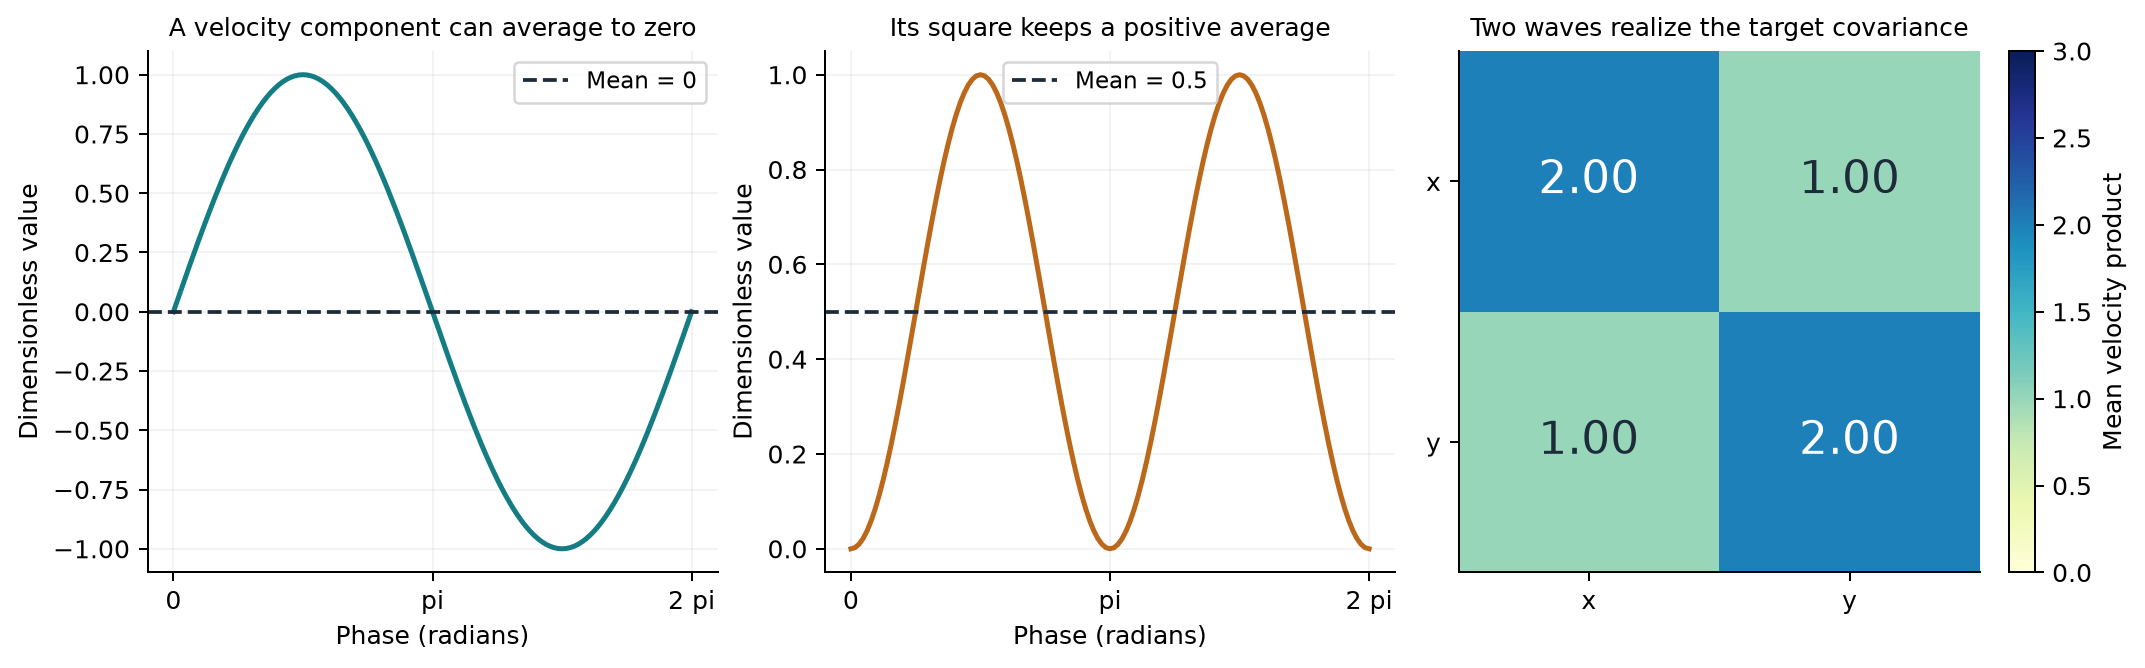

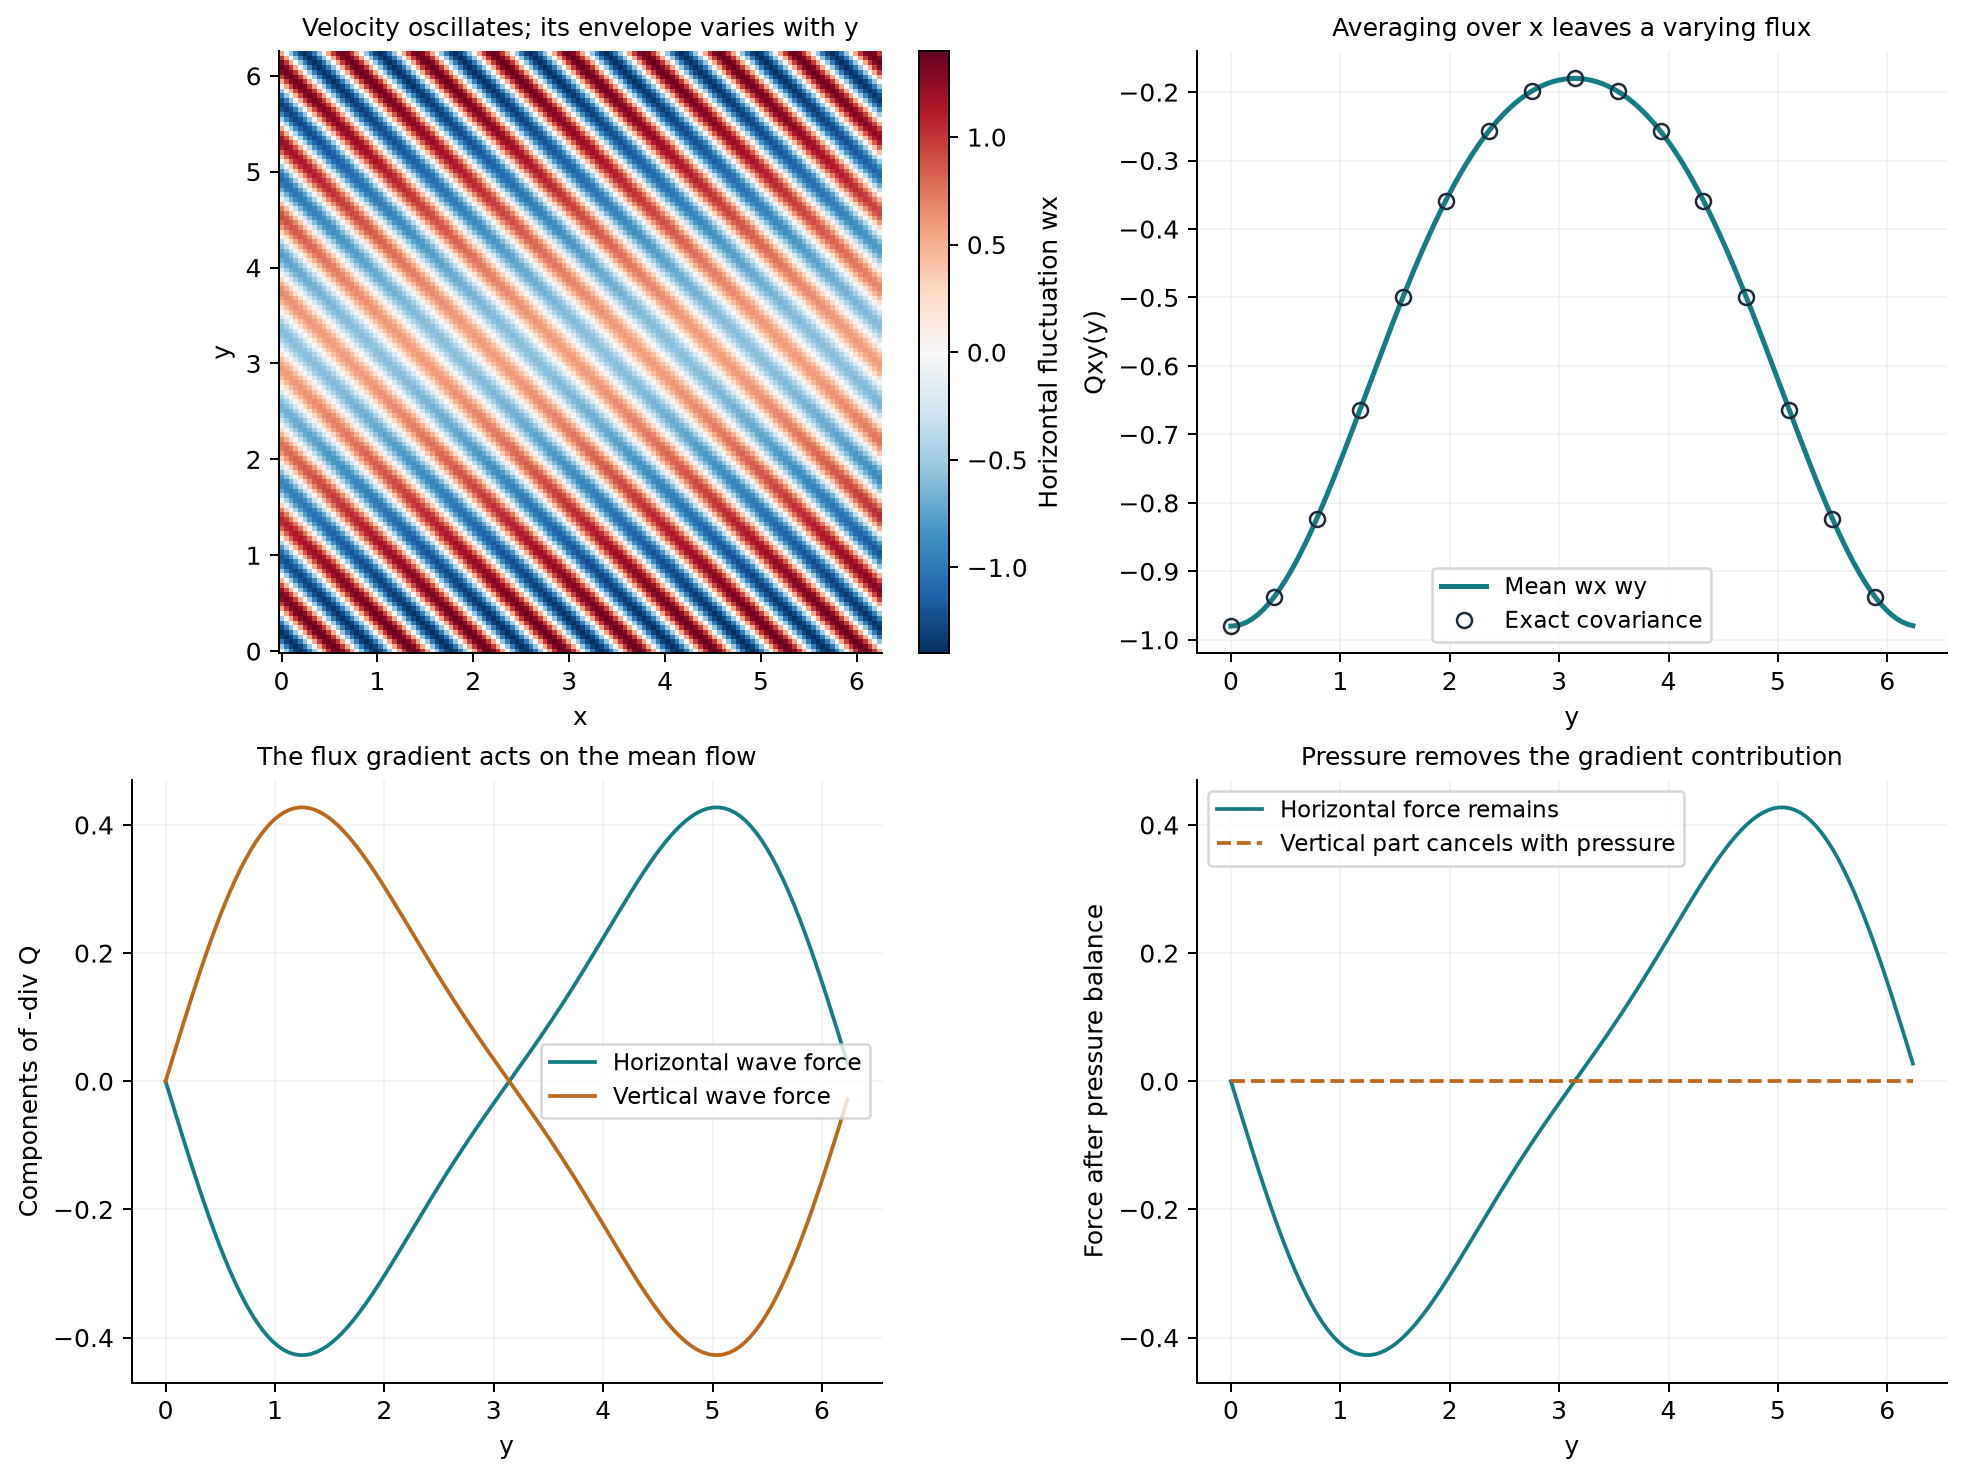

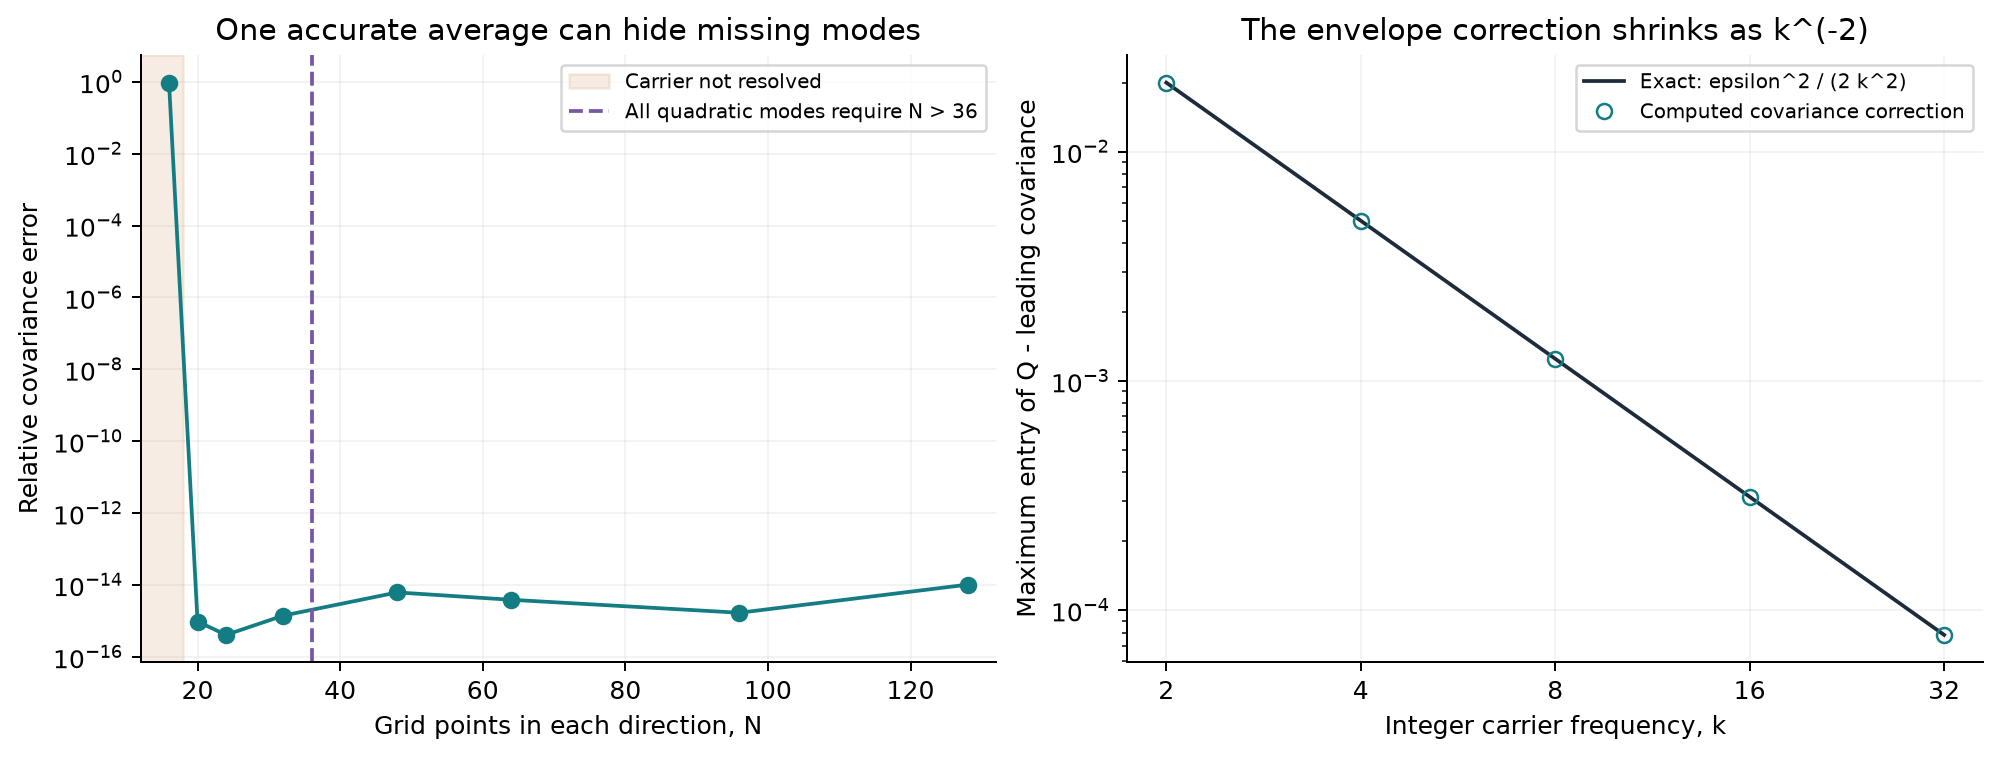

In [6]:
for name in ('01_zero_mean_nonzero_stress','02_spatial_transport','03_resolution_and_envelope'):
    display(Image(filename=str(WRITING/'figures'/f'{name}.png')))